In [8]:
from cfe.regression import Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cfe.regression as rgsn

Ethiopia_URL = "https://docs.google.com/spreadsheets/d/1qOZi1FqAS89x461pCIgwRaAfpBw5aUp7kBbp0tQKI_E/edit?usp=sharing"
url = Ethiopia_URL.replace("/edit?usp=sharing", "/export?format=xlsx")

fct = pd.read_excel(url, sheet_name="FCT")
fct = fct.rename(columns={'index': 'j'})
fct = fct.set_index('j')
fct.columns.name = 'n'
fct = fct.apply(lambda x: pd.to_numeric(x, errors='coerce'))

fct.index = fct.index.astype(str).str.strip()

fct.head()

n,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,...,Zinc,Fiber,Folate,Carbohydrate,Niacin,Phosphorus,Potassium,Riboflavin,Thiamin,Vitamin K
j,,,,,,,,,,,,,,,,,,,,,
Avocado,1601.338432,20.0,70,0,20.7,100,2.57,0,120.0,290.0,...,6.4,67.0,810.0,85.3,17.38,520.0,4850.0,1.3,0.67,210.0
Banana,890.000000,11.0,30,0,1.0,87,4.00,0,50.0,270.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Barley,3490.000000,123.0,0,0,10.0,0,2.00,0,260.0,920.0,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beef,3230.000000,249.0,0,0,0.0,0,3.00,19,40.0,230.0,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beer,410.000000,3.0,0,0,0.0,0,1.00,0,50.0,60.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
ET_exp = pd.read_excel(url, sheet_name="Food Expenditures (2018-19)")
ET_hh  = pd.read_excel(url, sheet_name="Household Characteristics")
ET_p   = pd.read_excel(url, sheet_name="Food Prices (2018-19)")

for df in [ET_exp, ET_hh]:
    df['i'] = pd.to_numeric(df['i'], errors='coerce')
    df['t'] = df['t'].astype(str).str.strip()
    df['m'] = df['m'].astype(str).str.strip().str.lower()

In [10]:
def prepare_data(URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = pd.read_excel(url, sheet_name=FE_Sheet)
    d = pd.read_excel(url, sheet_name=household_sheet)

    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = df['m'].astype(str).str.strip().str.lower()

    x = x.pivot_table(
        index=['i','t','m'],
        columns='j',
        values='Expenditure',
        aggfunc='sum'
    )

    x = x.replace(0, np.nan)

    # IMPORTANT: Regression needs long Series with index i,t,m,j
    y = np.log(x).stack()
    y.index.names = ['i','t','m','j']

    d.columns.name = 'k'
    d = d.loc[:, ~d.columns.duplicated()]
    d = d.groupby(['i','t','m'], as_index=False).first()
    d = d.set_index(['i','t','m'])
    d.index.names = ['i','t','m']
    d = d.fillna(0)

    return y, d

In [12]:
# Use observed expenditures as food demand system output
ET_xhat = ET_y.copy()

# Prices
ET_p = pd.read_excel(url, sheet_name="Food Prices (2018-19)")

ET_pbar = ET_p.pivot_table(
    columns='j',
    values='Price',
    aggfunc='mean'
).iloc[0]

# Quantities = expenditures / prices
ET_qhat = ET_xhat.unstack('j')

common_foods = ET_qhat.columns.intersection(ET_pbar.index)
ET_qhat = ET_qhat[common_foods].div(ET_pbar[common_foods], axis=1)

ET_qhat = ET_qhat.dropna(how='all')
ET_qhat.head()

j                             Avocado  Banana  Barley  Beef      Beer  \
i            t       m                                                  
1.203020e+13 2018-19 gambela      NaN     NaN     NaN   NaN  0.045808   
1.010109e+16 2018-19 tigray       NaN     NaN     NaN   NaN       NaN   
                     tigray       NaN     NaN     NaN   NaN       NaN   
                     tigray   0.10683     NaN     NaN   NaN       NaN   
                     tigray       NaN     NaN     NaN   NaN       NaN   

j                             Beetroot   Berbere  Boye/Yam  Bread/biscuit  \
i            t       m                                                      
1.203020e+13 2018-19 gambela  0.171446  0.030292       NaN            NaN   
1.010109e+16 2018-19 tigray        NaN       NaN       NaN            NaN   
                     tigray        NaN  0.019676       NaN            NaN   
                     tigray        NaN  0.036235       NaN       0.074928   
                     tigray        NaN       NaN       NaN            NaN   

j                             Bula  ...   Sorghum     Sugar  Sun Flower  \
i            t       m              ...                                   
1.203020e+13 2018-19 gambela   NaN  ...  0.105911  0.086254         NaN   
1.010109e+16 2018-19 tigray    NaN  ...       NaN  0.065031         NaN   
                     tigray    NaN  ...       NaN  0.054420         NaN   
                     tigray    NaN  ...       NaN  0.083172         NaN   
                     tigray    NaN  ...       NaN  0.102380         NaN   

j                             Sweet potato       Tea      Teff  Tella  \
i            t       m                                                  
1.203020e+13 2018-19 gambela           NaN       NaN  0.159623    NaN   
1.010109e+16 2018-19 tigray            NaN       NaN       NaN    NaN   
                     tigray            NaN       NaN       NaN    NaN   
                     tigray            NaN  0.031482       NaN    NaN   
                     tigray            NaN  0.028278       NaN    NaN   

j                               Tomato     Vetch  Wheat  
i            t       m                                   
1.203020e+13 2018-19 gambela       NaN  0.117238    NaN  
1.010109e+16 2018-19 tigray        NaN       NaN    NaN  
                     tigray        NaN       NaN    NaN  
                     tigray   0.129736       NaN    NaN  
                     tigray        NaN       NaN    NaN  

[5 rows x 73 columns]

In [18]:
#Nutrient Demand System#

In [13]:
fct.index = fct.index.astype(str).str.strip()
ET_qhat.columns = ET_qhat.columns.astype(str).str.strip()

fct0, c0 = fct.align(ET_qhat.T, axis=0, join='inner')

fct0 = fct0.apply(pd.to_numeric, errors='coerce').fillna(0)
c0 = c0.apply(pd.to_numeric, errors='coerce').fillna(0)

ET_N = fct0.T @ c0
ET_N = ET_N.loc[~ET_N.index.duplicated()]

ET_N.head()

i         1.203020e+13 1.010109e+16                                        \
t              2018-19      2018-19                                         
m              gambela       tigray       tigray       tigray      tigray   
n                                                                           
Energy     2112.884113   325.445295   825.933955  2030.815094  837.811584   
Protein      45.104516     3.258629    10.616975    58.034355    4.031559   
Vitamin A     8.724466     0.000000  1124.350677  2335.496467    0.000000   
Vitamin D     0.000000     0.000000     0.000000    10.586304    0.000000   
Vitamin E    15.389441     0.000000    10.626806    16.983038    0.405060   

i                                                                          \
t                                                                           
m               tigray       tigray       tigray      tigray       tigray   
n                                                                           
Energy      881.387580   816.640494   924.473779  934.638153   877.400100   
Protein      13.452150     9.930414    15.330701   10.674036    24.594483   
Vitamin A  1088.862200  1088.862200  1088.862200    0.000000  1088.862200   
Vitamin D     0.000000     0.000000     0.000000    0.000000     0.000000   
Vitamin E     9.560489     9.057947    10.412065   10.591316    11.541005   

i          ... 1.501011e+17                                         \
t          ...      2018-19                                          
m          ...    dire dawa    dire dawa    dire dawa    dire dawa   
n          ...                                                       
Energy     ...  2310.319969  2706.116506  1366.990290  2700.143489   
Protein    ...    45.959204    76.771723    27.894518    75.858982   
Vitamin A  ...     6.948284  2704.663810    13.701677  1150.421549   
Vitamin D  ...     0.000000    12.563871     0.000000    11.230591   
Vitamin E  ...    14.933588    21.601544     0.405060     3.389398   

i                                                                       \
t                                                                        
m           dire dawa    dire dawa   dire dawa   dire dawa   dire dawa   
n                                                                        
Energy     728.506913  2144.822205  716.448893  128.480356  800.229633   
Protein     16.996930    45.914665   16.394732    9.229364   19.116193   
Vitamin A    0.764293    16.320234    1.639570    1.176631    1.853280   
Vitamin D    0.000000     0.000000    0.000000    0.000000    0.000000   
Vitamin E    0.316714     0.316714   12.543340    0.000000   15.854614   

i                      
t                      
m           dire dawa  
n                      
Energy     703.886538  
Protein     16.213549  
Vitamin A    1.581033  
Vitamin D    0.000000  
Vitamin E   13.210585  

[5 rows x 5089 columns]

In [14]:
ET_N_summary = ET_N.mean(axis=1).to_frame("Average Nutrient Consumption")

ET_N_summary.head(15)

,Average Nutrient Consumption
n,
Energy,1739.851580
Protein,39.607621
Vitamin A,756.235380
Vitamin D,2.219704
Vitamin E,8.885148
Vitamin C,87.762167
Vitamin B-6,1.842386
Vitamin B-12,2.324223
Calcium,473.019706


In [15]:
ET_N_households = ET_N.T

ET_N_households.head()

n                                  Energy    Protein    Vitamin A  Vitamin D  \
i            t       m                                                         
1.203020e+13 2018-19 gambela  2112.884113  45.104516     8.724466   0.000000   
1.010109e+16 2018-19 tigray    325.445295   3.258629     0.000000   0.000000   
                     tigray    825.933955  10.616975  1124.350677   0.000000   
                     tigray   2030.815094  58.034355  2335.496467  10.586304   
                     tigray    837.811584   4.031559     0.000000   0.000000   

n                             Vitamin E   Vitamin C  Vitamin B-6  \
i            t       m                                             
1.203020e+13 2018-19 gambela  15.389441  113.731870     3.416866   
1.010109e+16 2018-19 tigray    0.000000    4.546157     0.061435   
                     tigray   10.626806  117.197870     1.340343   
                     tigray   16.983038  113.535635     2.440426   
                     tigray    0.405060    6.092178     0.082327   

n                             Vitamin B-12     Calcium   Magnesium  ...  \
i            t       m                                              ...   
1.203020e+13 2018-19 gambela      0.398532  768.393838  452.681997  ...   
1.010109e+16 2018-19 tigray       0.000000  106.354788  105.332655  ...   
                     tigray       0.000000  318.993099  273.496058  ...   
                     tigray      11.028228  510.052282  393.957279  ...   
                     tigray       0.000000  135.403951  128.408035  ...   

n                                 Zinc      Fiber      Folate  Carbohydrate  \
i            t       m                                                        
1.203020e+13 2018-19 gambela  9.941217  18.672798  202.284567    146.971587   
1.010109e+16 2018-19 tigray   0.122869   0.000000    0.000000      0.000000   
                     tigray   1.713460   1.511478   37.248608      9.479005   
                     tigray   6.856736   7.577211  103.678812     11.523394   
                     tigray   0.164653   0.000000    0.000000      0.000000   

n                               Niacin  Phosphorus    Potassium  Riboflavin  \
i            t       m                                                        
1.203020e+13 2018-19 gambela  6.501500  816.181196  1446.758192    0.582010   
1.010109e+16 2018-19 tigray   0.000000    0.000000     0.000000    0.000000   
                     tigray   0.471048   12.782693   179.275158    0.048367   
                     tigray   2.227754   65.186544   595.197758    0.190406   
                     tigray   0.000000    0.000000     0.000000    0.000000   

n                              Thiamin  Vitamin K  
i            t       m                             
1.203020e+13 2018-19 gambela  0.763909   3.984238  
1.010109e+16 2018-19 tigray   0.000000   0.000000  
                     tigray   0.028177   1.963192  
                     tigray   0.091484  22.434286  
                     tigray   0.000000   0.000000  

[5 rows x 21 columns]

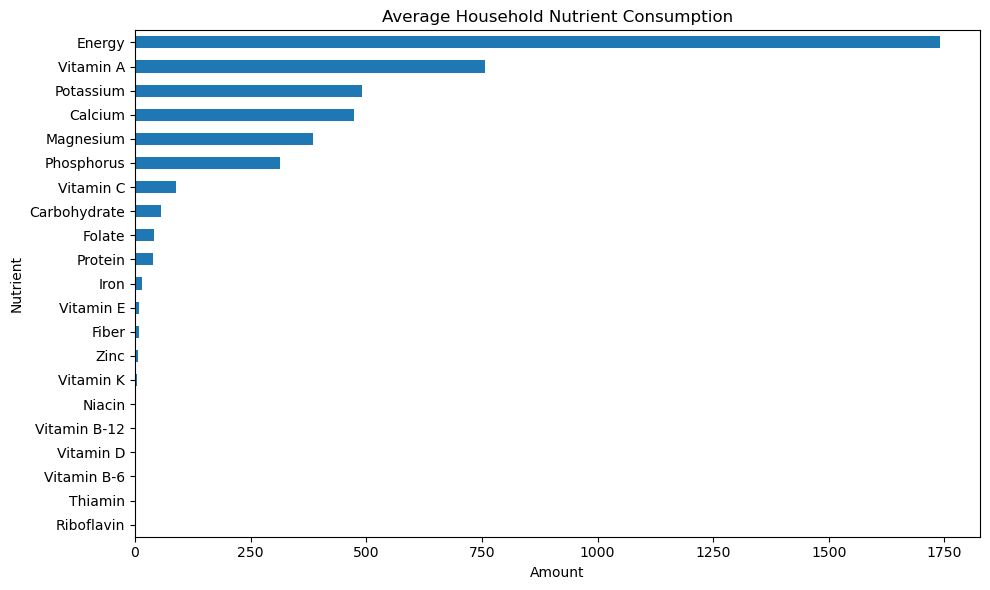

In [16]:
import matplotlib.pyplot as plt

# average across households
ET_N_summary = ET_N.mean(axis=1)

plt.figure(figsize=(10,6))
ET_N_summary.sort_values().plot(kind='barh')

plt.title("Average Household Nutrient Consumption")
plt.xlabel("Amount")
plt.ylabel("Nutrient")

plt.tight_layout()
plt.show()

In [24]:
ET_N_region = ET_N.T.groupby(level='m').mean().T

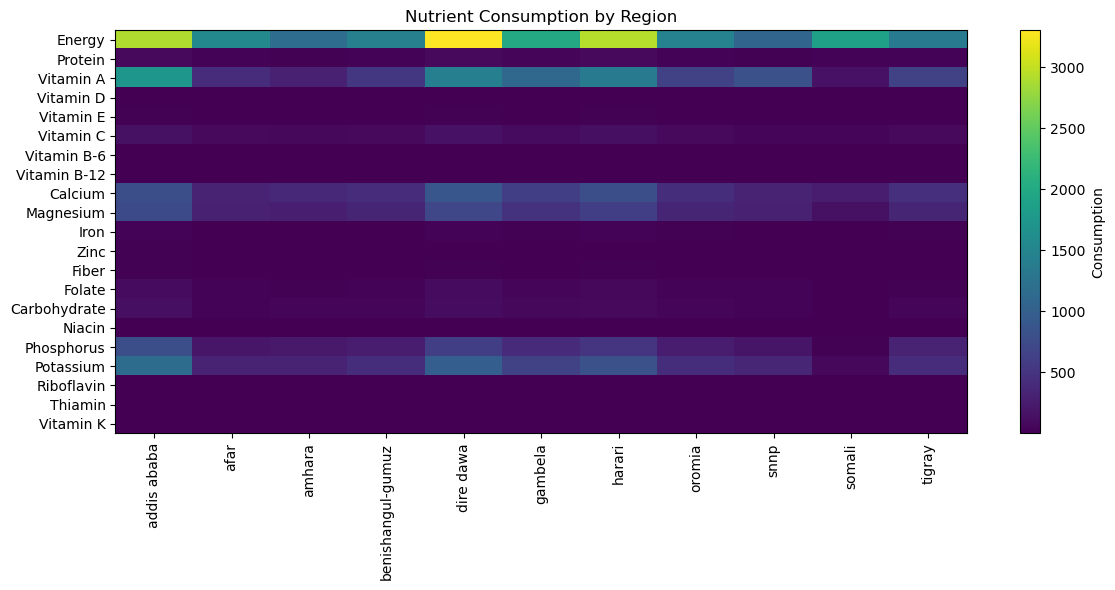

In [25]:
plt.figure(figsize=(12,6))
plt.imshow(ET_N_region, aspect='auto')

plt.colorbar(label='Consumption')
plt.yticks(range(len(ET_N_region.index)), ET_N_region.index)
plt.xticks(range(len(ET_N_region.columns)), ET_N_region.columns, rotation=90)

plt.title("Nutrient Consumption by Region")

plt.tight_layout()
plt.show()